In [340]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [342]:
data = pd.read_csv('mymoviedb.csv', lineterminator = '\n')

In [344]:
# To see if there are any missing values and the data types.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [346]:
# To look for duplicate values.
data.duplicated().sum()

0

In [348]:
data.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [350]:
# Changing the data type to datetime.
data['Release_Date'] = pd.to_datetime(data['Release_Date'])

# We just want the year to be there in the column.
data['Release_Date']=data['Release_Date'].dt.year

In [352]:
# Deleting the unwanted columns from the dataframe for better preview and analysis.
data.drop(['Overview','Original_Language','Poster_Url'],axis=1,inplace=True)

 **Categorizing Vote_Average column**
 
 We would cut the `Vote_Average values` and make 4 categories:
 `popular` `average` `below_avg` `not_popular` to describe it more using catigorize_col() function provided above.

In [355]:
def catigorize_col (data, col, labels):

    # Setting the edges to cut the column accordingly
    edges = [data[col].describe()['min'],
             data[col].describe()['25%'],
             data[col].describe()['50%'],
             data[col].describe()['75%'],
             data[col].describe()['max']]
    
    data[col] = pd.cut(data[col], edges, labels = labels, duplicates='drop')
    return data

In [357]:
# Define labels for edges
labels = ['not_popular', 'below_avg', 'average', 'popular']

# Categorize column based on labels and edges
catigorize_col(data, 'Vote_Average', labels)

# Confirming changes
data['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [359]:
# Searching for NaN values
data.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [361]:
# Dropping the Nan values
data.dropna(inplace=True)

In [363]:
data['Genre'] = data['Genre'].str.split(', ')
data=data.explode('Genre').reset_index(drop=True)

In [365]:
data['Genre'].value_counts()

Genre
Drama              3715
Comedy             3006
Action             2652
Thriller           2473
Adventure          1829
Romance            1461
Horror             1457
Animation          1426
Family             1405
Fantasy            1295
Science Fiction    1255
Crime              1235
Mystery             765
History             426
War                 307
Music               291
TV Movie            214
Documentary         203
Western             137
Name: count, dtype: int64

In [367]:
data.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [369]:
# Casting column into catagory.
data['Genre'] = data['Genre'].astype('category')

data['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [371]:
# To see no of unique data.
data.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64




# **Data Visualization**

In [374]:
sns.set_style('whitegrid')

# What is the most frequent genre in the dataset?

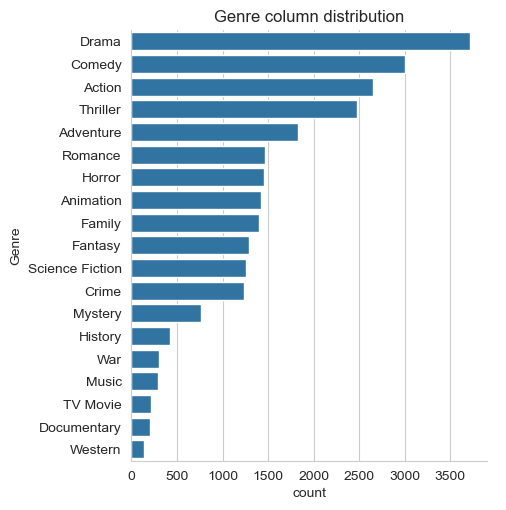

In [377]:
sns.catplot( y='Genre', data = data, kind = 'count', order = data['Genre'].value_counts().index)
plt.title('Genre column distribution')
plt.show()

 # What genres has highest votes ?

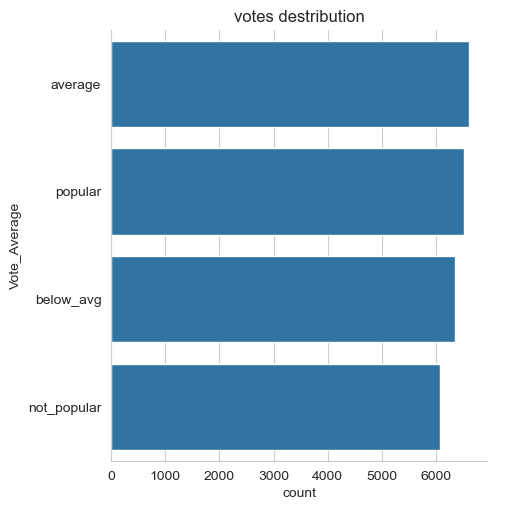

In [379]:
sns.catplot( y='Vote_Average' , data=data , kind='count' , order=data['Vote_Average'].value_counts().index )
plt.title('votes destribution')
plt.show()

 # Which movie got the highest popularity?  What is its genre?

In [381]:
data[data['Popularity'] == data['Popularity'].max()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
0,Spider-Man: No Way Home,5083.954,Action
1,Spider-Man: No Way Home,5083.954,Adventure
2,Spider-Man: No Way Home,5083.954,Science Fiction


# What movie got the lowest popularity? what s its genre?

In [384]:
data[data['Popularity'] == data['Popularity'].min()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
25546,The United States vs. Billie Holiday,13.354,Music
25547,The United States vs. Billie Holiday,13.354,Drama
25548,The United States vs. Billie Holiday,13.354,History
25549,Threads,13.354,War
25550,Threads,13.354,Drama
25551,Threads,13.354,Science Fiction


# Which year has the most filmed movies?

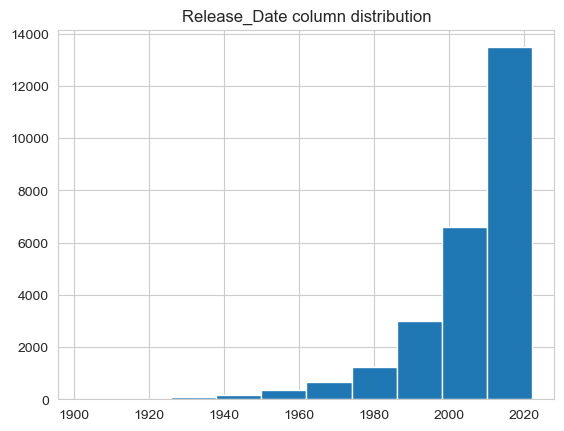

In [389]:
data['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()